In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
url = "https://shivani-workforce-analytics-project.s3.us-east-2.amazonaws.com/workforce_final_python.csv"
df = pd.read_csv(url)
df.head()

,department,job_role,salary,overtime,overtime_hours,hours_worked,projects_handled,performance_rating,productivity_score,years_at_company,attrition,hourly_rate,overtime_cost,efficiency_score,high_risk
0,Sales,Sales Executive,5993.0,Yes,15.0,55.0,8,3.0,0.6,6,Yes,37.45625,561.84375,0.037500,1
1,Research & Development,Research Scientist,5130.0,No,5.0,45.0,8,4.0,0.8,10,No,32.06250,160.31250,0.133333,0
2,Research & Development,Laboratory Technician,2090.0,Yes,15.0,55.0,3,3.0,0.6,0,Yes,13.06250,195.93750,0.037500,1
3,Research & Development,Research Scientist,2909.0,Yes,15.0,55.0,7,3.0,0.6,8,No,18.18125,272.71875,0.037500,1
4,Research & Development,Laboratory Technician,3468.0,No,5.0,45.0,6,3.0,0.6,2,No,21.67500,108.37500,0.100000,0


In [41]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   department          1470 non-null   object 
 1   job_role            1470 non-null   object 
 2   salary              1470 non-null   float64
 3   overtime            1470 non-null   object 
 4   overtime_hours      1470 non-null   float64
 5   hours_worked        1470 non-null   float64
 6   projects_handled    1470 non-null   int64  
 7   performance_rating  1470 non-null   float64
 8   productivity_score  1470 non-null   float64
 9   years_at_company    1470 non-null   int64  
 10  attrition           1470 non-null   object 
 11  hourly_rate         1470 non-null   float64
 12  overtime_cost       1470 non-null   float64
 13  efficiency_score    1470 non-null   float64
 14  high_risk           1470 non-null   int64  
dtypes: float64(8), int64(3), object(4)
memory usage: 172.4+

,salary,overtime_hours,hours_worked,projects_handled,performance_rating,productivity_score,years_at_company,hourly_rate,overtime_cost,efficiency_score,high_risk
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,6502.931293,7.829932,47.829932,5.550340,3.153741,0.630748,7.008163,40.643321,319.041263,0.086516,0.238776
std,4707.956783,4.506065,4.506065,1.701274,0.360824,0.072165,6.126525,29.424730,322.849489,0.031366,0.426480
min,1009.000000,5.000000,45.000000,3.000000,3.000000,0.600000,0.000000,6.306250,32.843750,0.037500,0.000000
25%,2911.000000,5.000000,45.000000,4.000000,3.000000,0.600000,3.000000,18.193750,117.179688,0.050000,0.000000
50%,4919.000000,5.000000,45.000000,6.000000,3.000000,0.600000,5.000000,30.743750,205.546875,0.100000,0.000000
75%,8379.000000,15.000000,55.000000,7.000000,3.000000,0.600000,9.000000,52.368750,413.179688,0.100000,0.000000
max,19999.000000,15.000000,55.000000,8.000000,4.000000,0.800000,40.000000,124.993750,1861.781250,0.133333,1.000000


In [42]:
df.isnull().sum()

department            0
job_role              0
salary                0
overtime              0
overtime_hours        0
hours_worked          0
projects_handled      0
performance_rating    0
productivity_score    0
years_at_company      0
attrition             0
hourly_rate           0
overtime_cost         0
efficiency_score      0
high_risk             0
dtype: int64

In [43]:
df.fillna(0, inplace=True)

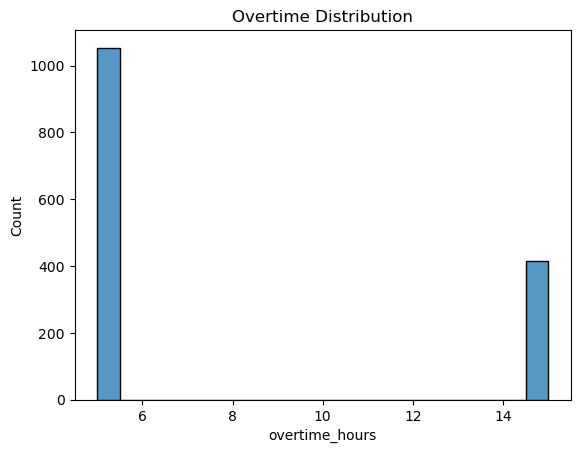

In [44]:
#OVERTIME DISTRIBUTION
sns.histplot(df['overtime_hours'], bins=20)
plt.title("Overtime Distribution")
plt.show()

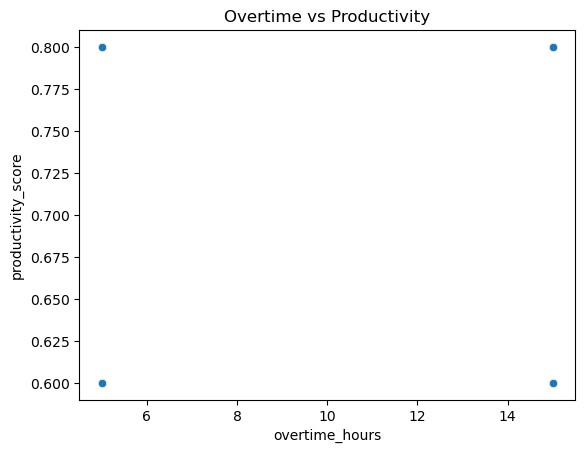

In [45]:
#PRODUCTIVITY VS OVERTIME
sns.scatterplot(x='overtime_hours', y='productivity_score', data=df)
plt.title("Overtime vs Productivity")
plt.show()

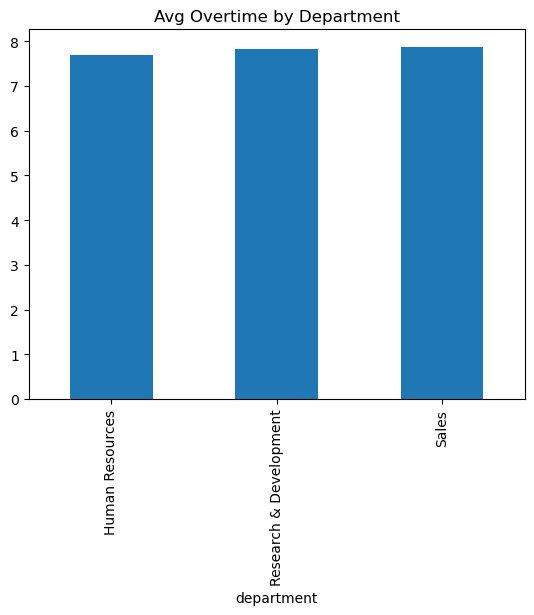

In [46]:
#DEPARTMENT ANALYSIS
df.groupby('department')['overtime_hours'].mean().plot(kind='bar')
plt.title("Avg Overtime by Department")
plt.show()

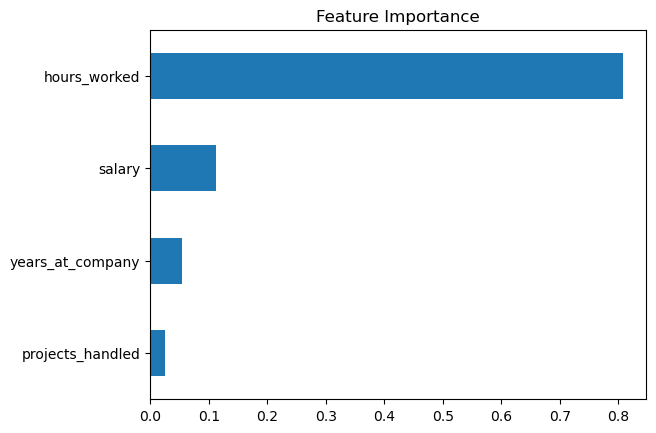

In [47]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [48]:
#CREATE COST FEATURE
df['hourly_rate'] = df['salary'] / 160
df['overtime_cost'] = df['overtime_hours'] * df['hourly_rate']

In [49]:
#CREATE EFFICIENCY SCORE
df['efficiency_score'] = df['productivity_score'] / (df['overtime_hours'] + 1)

In [50]:
#CREATE RISK LABEL
df['high_risk'] = np.where(
    (df['overtime_hours'] > 10) & (df['productivity_score'] < 0.65),
    1,
    0
)

In [51]:
from sklearn.model_selection import train_test_split

X = df[['hours_worked', 'projects_handled', 'years_at_company', 'salary']]
y = df['high_risk']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [53]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       206
           1       0.89      0.97      0.92        88

    accuracy                           0.95       294
   macro avg       0.94      0.96      0.94       294
weighted avg       0.96      0.95      0.95       294



In [56]:
df.to_csv("workforce_final_python.csv", index=False)